# **TRABAJO PRÁCTICO N° 1**
## **Minería de Datos**


2do Cuatrimestre - Año 2026

**Integrantes:**

* Bartomioli, Ornella
* Ruiz, Carolina

**Docentes:** Flavio E. Spetale - Ramiro Gatti - Julieta López Ceratto

### Importacion y carga del dataset

In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Instalación de librerías faltantes
#!pip install feature_engine

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from feature_engine.outliers import Winsorizer # remoción de outliers
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.metrics import silhouette_score,silhouette_samples

from sklearn.decomposition import PCA
from sklearn.manifold import MDS, Isomap, TSNE

# para evitar mensajes de Warning y similares
import warnings
from scipy.sparse import SparseEfficiencyWarning

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.manifold')
warnings.filterwarnings('ignore', category=SparseEfficiencyWarning)

In [2]:
# Carga y visuaización del conjunto de Datos
datos = pd.read_csv("penguins_size.csv",sep=';')
datos.head()

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo,Unnamed: 6,Unnamed: 7
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE,NaN,NaN
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE,NaN,NaN
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE,NaN,NaN
3,Adelie Penguin,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE,NaN,NaN


### **Análisis de las variables previo a la limpieza**

In [3]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  347 non-null    str    
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     337 non-null    str    
 6   Unnamed: 6               0 non-null      float64
 7   Unnamed: 7               0 non-null      float64
dtypes: float64(6), str(2)
memory usage: 28.4 KB


Para un primer analisis del dataset, se puede confirmar que:
* Tenemos 347 registros, 8 columnas en total.
* Entre sus variables hay 2 cuanlitativas (Especie y Sexo) y 6 cuantitativas continuas (Longitud Culmen (mm), Profundidad Culmen (mm), Longitud Aleta (mm), Masa corporal (g), Unnamed: 6, Unnamed: 7)
* Analizando los nulos, podemos observar que las columnas Unnamed: 6 y Unnamed: 7 estan vacias, todo su contenido es nulo y las demas variables cuantitativas tienen 2 nulos cada una.

### **1) Análisis y limpieza de datos**

In [4]:
datos = datos.drop(columns=['Unnamed: 6', 'Unnamed: 7'])

In [5]:
# Eliminación de espacios en blanco
datos.columns = datos.columns.str.strip()

In [6]:
datos.duplicated().sum()

np.int64(3)

In [7]:
# Traemos los duplicados, incluidos los originales
datos[datos.duplicated(keep=False)].sort_values(by="Especie")

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
63,Adelie Penguin,41.1,18.2,192.0,4050.0,MALE
126,Adelie Penguin,38.8,17.6,191.0,3275.0,FEMALE
127,Adelie Penguin,38.8,17.6,191.0,3275.0,FEMALE
206,Adelie Penguin,41.1,18.2,192.0,4050.0,MALE
254,Gentoo penguin,59.6,17.0,230.0,6050.0,MALE
256,Gentoo penguin,59.6,17.0,230.0,6050.0,MALE


In [8]:
# Eliminación de duplicados
datos = datos.drop_duplicates()

In [9]:
# Verificación post eliminación de duplicados
datos.info()

<class 'pandas.DataFrame'>
Index: 344 entries, 0 to 346
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  344 non-null    str    
 1   Longitud Culmen (mm)     342 non-null    float64
 2   Profundidad Culmen (mm)  342 non-null    float64
 3   Longitud Aleta (mm)      342 non-null    float64
 4   Masa corporal (g)        342 non-null    float64
 5   Sexo                     334 non-null    str    
dtypes: float64(4), str(2)
memory usage: 25.4 KB


El dataset pasa a tener 344 entradas, con cinco columnas de seis con valores nulos.

In [10]:
# Observaciones nulas:
datos.isnull().sum()

Especie                     0
Longitud Culmen (mm)        2
Profundidad Culmen (mm)     2
Longitud Aleta (mm)         2
Masa corporal (g)           2
Sexo                       10
dtype: int64

In [11]:
# Registros con valores nulos en cualquier columna
datos[datos.isna().any(axis=1)]

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
3,Adelie Penguin,NaN,NaN,NaN,NaN,NaN
8,Adelie Penguin,34.1,18.1,193.0,3475.0,NaN
9,Adelie Penguin,42.0,20.2,190.0,4250.0,NaN
10,Adelie Penguin,37.8,17.1,186.0,3300.0,NaN
11,Adelie Penguin,37.8,17.3,180.0,3700.0,NaN
47,Adelie Penguin,37.5,18.9,179.0,2975.0,NaN
248,Gentoo penguin,44.5,14.3,216.0,4100.0,NaN
289,Gentoo penguin,46.2,14.4,214.0,4650.0,NaN
327,Gentoo penguin,47.3,13.8,216.0,4725.0,NaN
342,Gentoo penguin,NaN,NaN,NaN,NaN,NaN


In [12]:
filas_nulas = datos.isna().any(axis=1).sum()
print(f"{filas_nulas} de {len(datos)} filas ({filas_nulas / len(datos):.2%} del dataset) -> no supera el umbral de 5%")

10 de 344 filas (2.91% del dataset) -> no supera el umbral de 5%


In [13]:
# Simplificación de nombres de especies
datos['Especie'] = datos['Especie'].replace({
    'Adelie Penguin': 'Adelie',
    'Gentoo penguin': 'Gentoo',
    'Chinstrap penguin': 'Chinstrap',
})

In [14]:
datos['Especie'].value_counts()

Especie
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [15]:
datos['Sexo'].value_counts()

Sexo
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

In [16]:
# Eliminación de registro cuyo sexo no fue definido
datos = datos[datos['Sexo'] != '.']

In [17]:
datos = datos.dropna().reset_index(drop=True)

* Valores faltantes (NaN): Se identificaron inicialmente 10 observaciones con datos incompletos.

    * 2 registros carecían de todas las mediciones morfométricas y de sexo (conservando únicamente la especie), por lo que fueron eliminados al no aportar información cuantitativa útil.

    * 8 registros poseían mediciones corporales completas pero valor nulo en Sexo. Al verificar su distribución, se constató que pertenecían a las especies mayoritarias (Adelie y Gentoo), sin comprometer la muestra de la especie minoritaria (Chinstrap). Dado que representan menos del 3% del total muestral, se decidió descartarlos para evitar sesgos artificiales en el dimorfismo sexual y preservar la distribución natural de las variables.

* Valor anómalo en Sexo: Se detectó una observación con el valor inválido "." en lugar de una categoría biológica válida, el cual fue filtrado del conjunto de datos.

* Estandarización de Especie: Se corrigió una inconsistencia de mayúsculas entre categorías ("Adelie Penguin" con mayúscula frente a "Gentoo penguin" y "Chinstrap penguin" con minúscula). Se aplicó un mapeo uniforme para homogeneizar las etiquetas a: Adelie, Gentoo y Chinstrap.

### Analisis y modificaciones en las variables cualitativas

In [18]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  333 non-null    str    
 1   Longitud Culmen (mm)     333 non-null    float64
 2   Profundidad Culmen (mm)  333 non-null    float64
 3   Longitud Aleta (mm)      333 non-null    float64
 4   Masa corporal (g)        333 non-null    float64
 5   Sexo                     333 non-null    str    
dtypes: float64(4), str(2)
memory usage: 19.6 KB


La variable 'Sexo' aunque matemáticamente puede incluirse y presenta varianza, se trata de una variable categórica nominal, por lo que las distancias y relaciones lineales no tienen un significado real en este caso.

### **Análisis de las variables post limpieza**

**Variables Continuas (Numéricas):**

* Longitud Culmen (mm): longitud del pico en milímetros.
* Profundidad Culmen (mm): grosor o profundidad del pico en milímetros.
* Longitud Aleta (mm): largo de la aleta en milímetros.
* Masa corporal (g): peso corporal en gramos.

**Variables Categóricas (Cualitativas):**

* Especie (Categórica nominal / Variable objetivo): posee tres categorías (Adelie, Chinstrap y Gentoo).  
* Sexo (Categórica binaria / dicotómica): posee dos categorías válidas (MALE y FEMALE).

In [19]:
datos.describe()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


***Longitud del Culmen (mm):***

**Media:** 43.99 mm | **Mediana:** 44.50 mm  
La media y la mediana son muy similares, lo que sugiere una distribución 
aproximadamente simétrica.

**Rango:** 32.1 mm – 59.6 mm  
**Desviación estándar:** 5.47 mm

Indica una variabilidad moderada entre los individuos.

---
***Profundidad del Culmen (mm):***

**Media:** 17.16 mm | **Mediana:** 17.30 mm  
Los valores son prácticamente coincidentes, lo que sugiere una distribución 
simétrica para esta variable.

**Rango:** 13.1 mm – 21.5 mm  
**Desviación estándar:** 1.97 mm

Denota escasa dispersión en la profundidad del pico.

---
***Longitud de Aleta (mm):***

**Media:** 200.97 mm | **Mediana:** 197 mm  
La media es levemente mayor que la mediana, lo que podría indicar la 
presencia de individuos con aletas más largas y una asimetría hacia la 
derecha.

**Rango:** 172 mm – 231 mm  
**Desviación estándar:** 14.02 mm

---
***Masa Corporal (g):***

**Media:** 4207.06 g | **Mediana:** 4050 g  
Nuevamente la media supera a la mediana, lo que reafirma la presencia de 
individuos de mayor tamaño y peso.

**Rango:** 2700 g – 6300 g  
**Desviación estándar:** 805.22 g

Elevada desviación estándar, lo que indica alta variabilidad.

### **Analisis y visualizaciones:**

Se realizaron boxplots para cada variable numérica con el objetivo de identificar la presencia de valores atípicos.

Se aprecia claramente las diferencias entre los grupos en las diferentes medidas.

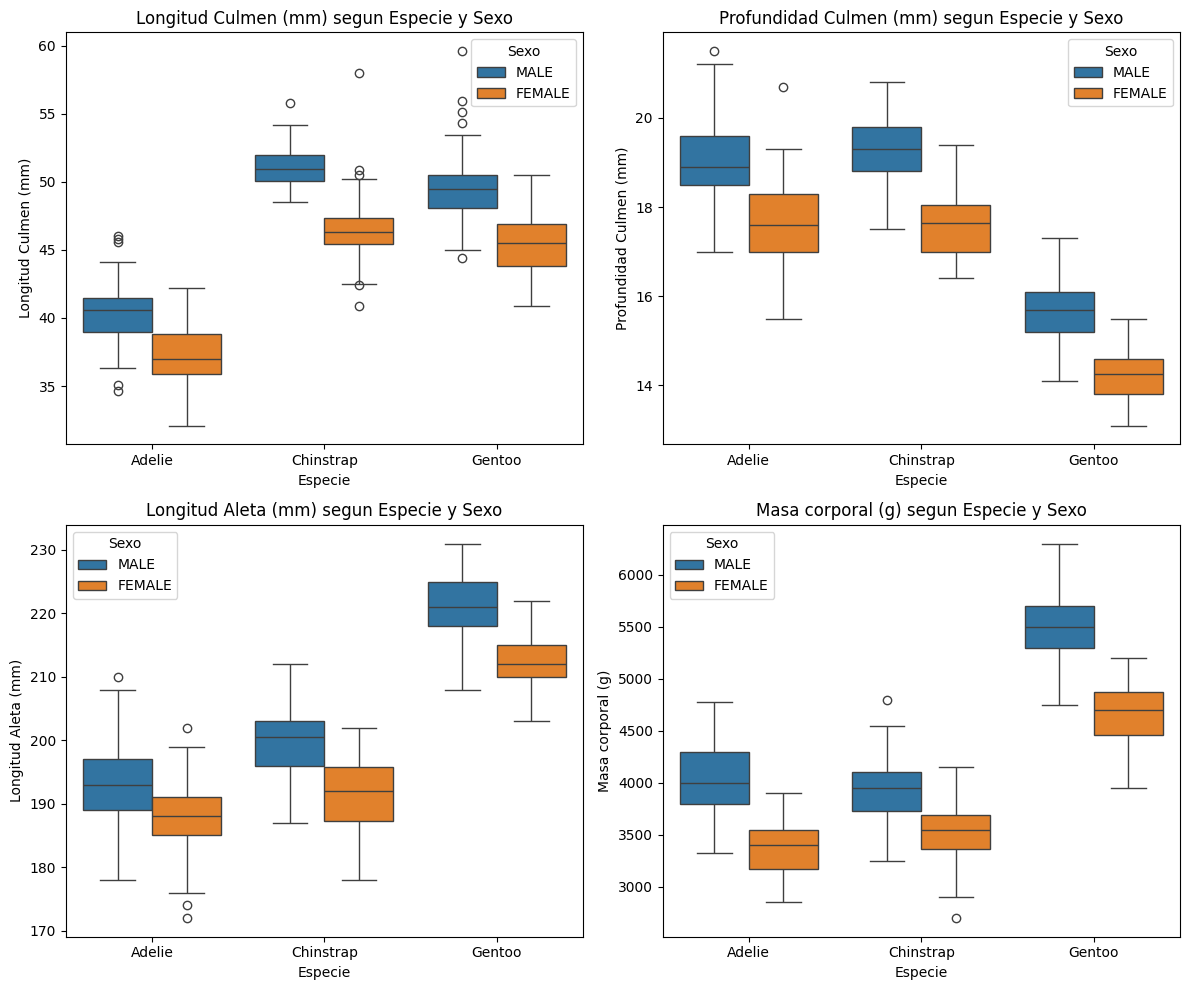

In [20]:
cols_num = ['Longitud Culmen (mm)',	'Profundidad Culmen (mm)',	'Longitud Aleta (mm)',	'Masa corporal (g)']
plt.figure(figsize=(12, 10))

for i, col in enumerate(cols_num):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x="Especie", y=col, hue='Sexo', data=datos)
    plt.title(f"{col} segun Especie y Sexo")

plt.tight_layout()
plt.show()

Mediante el analisis de boxplots por especie y sexo se detectaron observaciones en los extremos de las distribuciones. Sin embargo, al verificar que todos los registros se encuentran dentro de rangos biologicos verosímilires y que no constituyen errores de medicion, se opto por conservarlos en su estado original para preservar la varianza natural y evitar alterar la estructura multivariada.

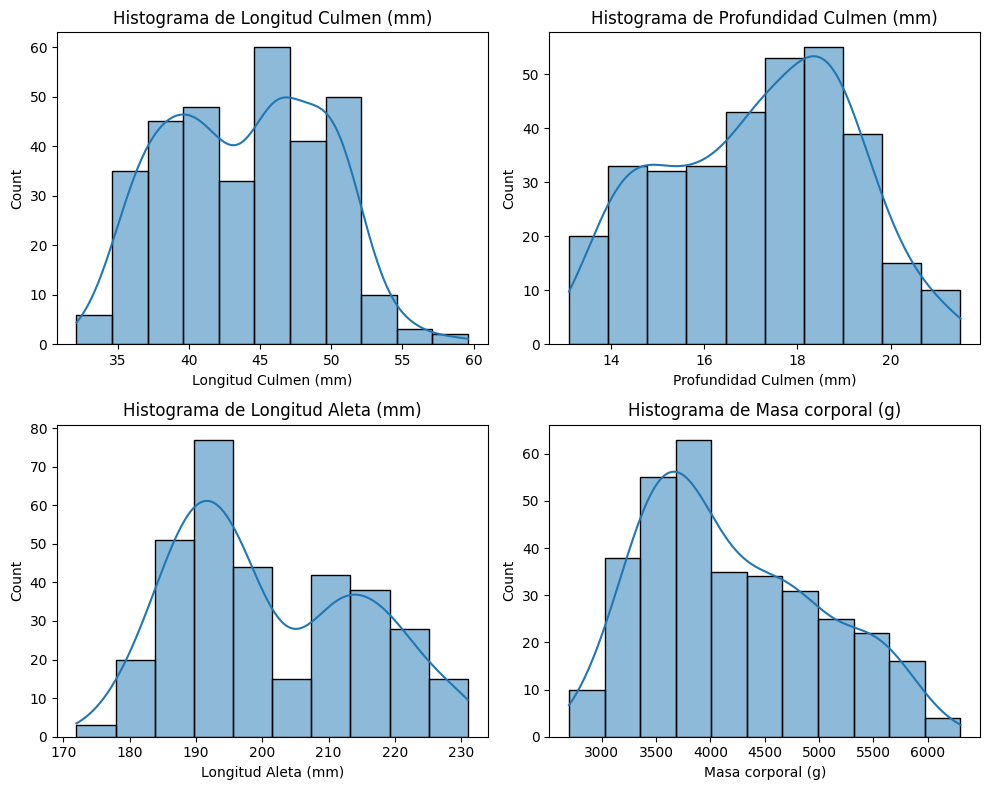

In [21]:
plt.figure(figsize=(10,8))

for i, col in enumerate(cols_num):
    plt.subplot(2, 2, i+1)
    sns.histplot(datos[col], kde=True)
    plt.title(f"Histograma de {col}")

plt.tight_layout()
plt.show()

Observaciones:

Los histogramas revelan que ninguna de las cuatro variables presenta una 
distribución unimodal. La longitud del culmen y la longitud de aleta exhiben 
una estructura claramente bimodal, con dos concentraciones separadas en torno 
a 39 y 47 mm en el primer caso, y a 190 y 215 mm en el segundo. La profundidad 
del culmen muestra un patrón análogo, con modas cercanas a 15 y 18 mm. La masa 
corporal presenta una asimetría positiva marcada, con una moda dominante 
alrededor de 3700 g y una cola extendida hacia los valores altos.

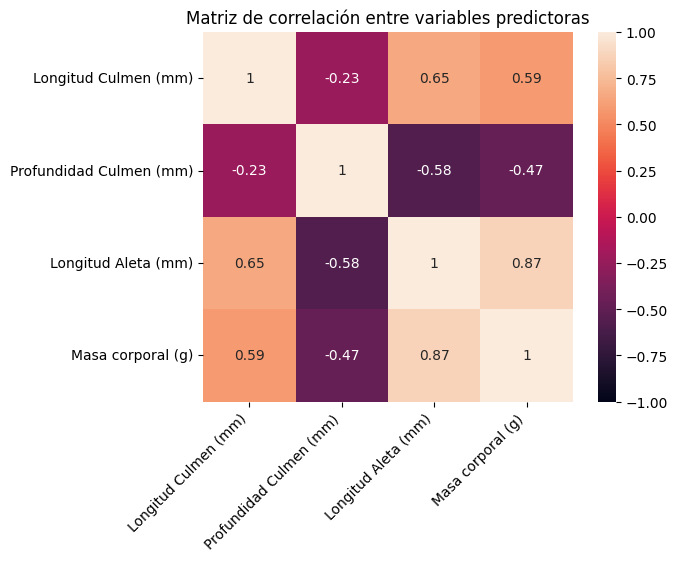

In [22]:
corr = datos.drop(columns=["Especie", "Sexo"]).corr()

ax = sns.heatmap(corr,vmin=-1, vmax=1, square=True,annot = True)
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,horizontalalignment='right')
plt.title('Matriz de correlación entre variables predictoras')
plt.show()

Se observa una fuerte correlación positiva entre Longitud de aleta y Masa corporal, lo que indica que los individuos con mayor tamaño tienden a tener mayor peso. Algo similar pasa entre Longitud Culmen y Masa, ya que a cuanta más masa, más logitud en las partes del cuerpo del animal.

También se identifican correlaciones negativas, como entre Profundidad del culmen y otras variables, lo que sugiere relaciones inversas entre ciertas características físicas.

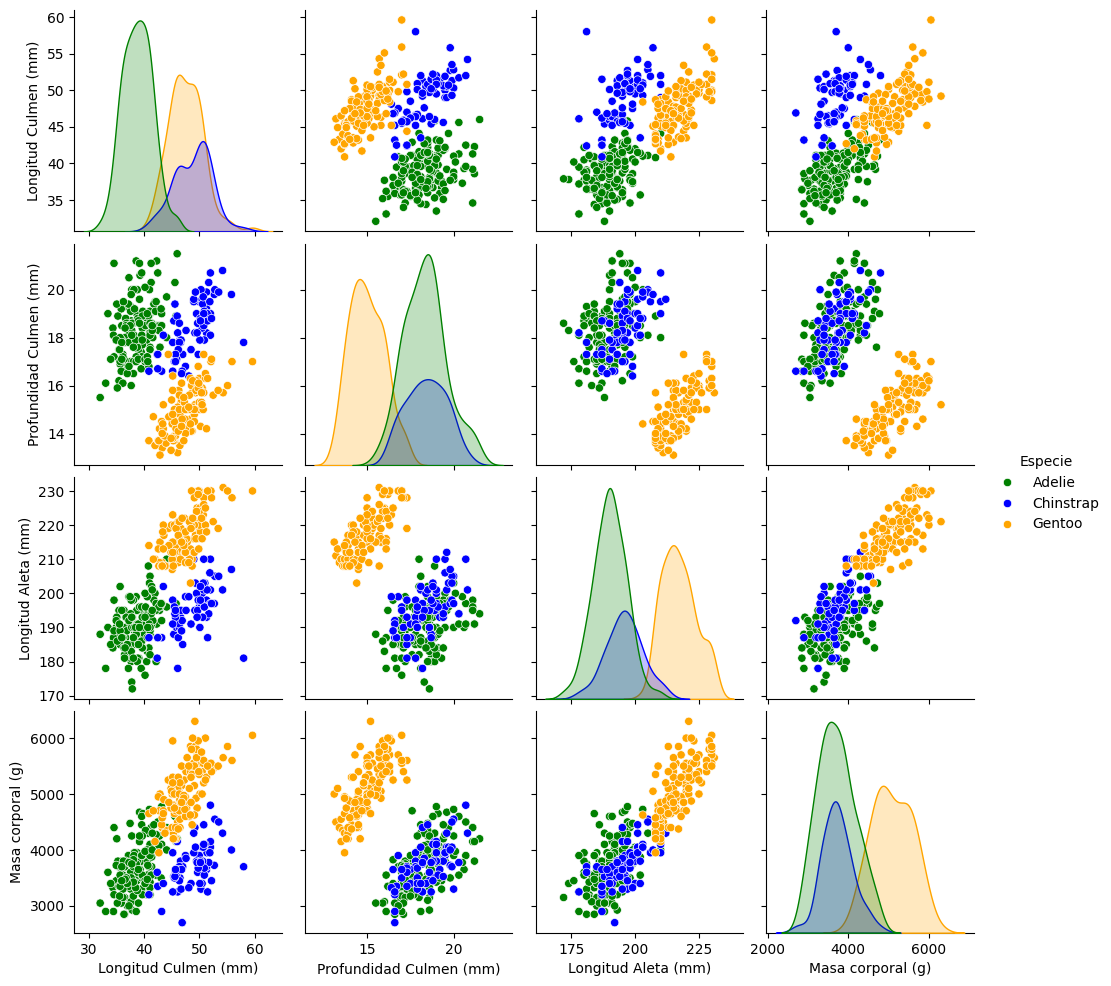

In [23]:
# Colores para representar cada grupo.
colores = { 'Adelie': 'green','Chinstrap': 'blue','Gentoo': 'orange' }

cols_drop = ['Sexo']
datos_plot = datos.drop(columns=cols_drop)

sns.pairplot(datos_plot, hue='Especie', palette=colores)
plt.show()

Ninguna variable aislada separa a las tres especies al mismo tiempo, de forma tajante. Gentoo se distingue fácilmente por tamaño corporal y aleta (variables "de tamaño"), mientras que diferenciar Adelie de Chinstrap requiere la forma del pico (longitud y profundidad de culmen combinadas), ya que en tamaño corporal son bastante similares. A continuación, se vuelve a diferenciar la cantidad de registros por especie, para subrayar la falta de representatividad más pareja.

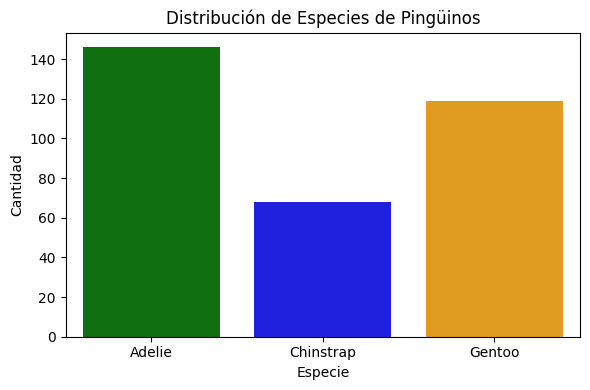

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(data=datos, x='Especie', hue='Especie', palette=colores, legend=False)
plt.title('Distribución de Especies de Pingüinos')
plt.xlabel('Especie')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### **2) PCA**

Observación:

La variable "Sexo" no fue incluida en los métodos de reducción de dimensionalidad ni clustering, ya que se trata de una variable categórica nominal. Incluirla como variable numérica implicaría asumir relaciones de orden y distancia que no tienen significado en este caso.

In [25]:
X = datos.drop(columns=['Especie', 'Sexo'])

In [26]:
# Estandarizacion:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada y acumulada
var_exp = pca.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

n_comp = len(var_exp)

In [28]:
# Explicabilidad por componente
pca.explained_variance_ratio_

array([0.68633893, 0.19452929, 0.09216063, 0.02697115])

In [29]:
# De forma acumulada
np.cumsum(pca.explained_variance_ratio_)

array([0.68633893, 0.88086822, 0.97302885, 1.        ])

### **Criterios de selección:**


#### A) Proporción de variancia acumulada (~75% -80%)

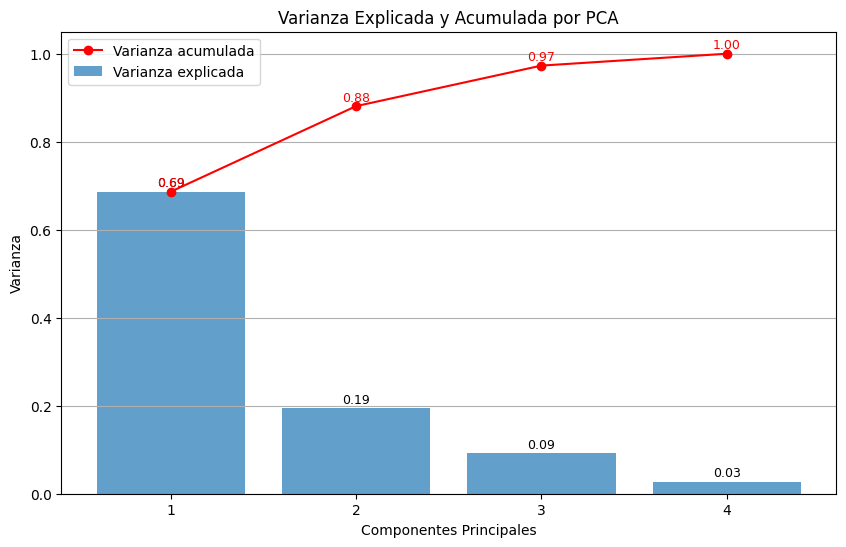

In [30]:
fig, ax = plt.subplots(figsize=(10,6))

# Barras: varianza explicada
bars = ax.bar(range(1, n_comp+1), var_exp, alpha=0.7, label='Varianza explicada')

# Línea: varianza acumulada
line = ax.plot(range(1, n_comp+1), var_cum, color='red', marker='o', label='Varianza acumulada')

# Etiquetas sobre las barras
for bar, v in zip(bars, var_exp):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.2f}",
            ha='center', va='bottom', fontsize=9)

# Etiquetas sobre la línea
for i, v in enumerate(var_cum, start=1):
    ax.text(i, v + 0.005, f"{v:.2f}", color='red',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Componentes Principales')
ax.set_ylabel('Varianza')
ax.set_title('Varianza Explicada y Acumulada por PCA')
ax.set_xticks(range(1, n_comp+1))
ax.legend()
ax.grid(axis='y')

plt.show()

A partir del gráfico anterior, se observa que el primer componente principal explica aproximadamente el 73% de la varianza total, mientras que el segundo componente aporta un 16% adicional, alcanzando cerca del 88% de varianza acumulada.

A partir del tercer componente, el incremento en la varianza explicada es mucho menor, lo que indica que los primeros dos componentes capturan la mayor parte de la información del conjunto de datos.

Por lo tanto, se puede concluir que utilizar 2 componentes principales es suficiente para representar adecuadamente los datos sin una pérdida significativa de información segun este criterio.

#### B) Criterio del Codo

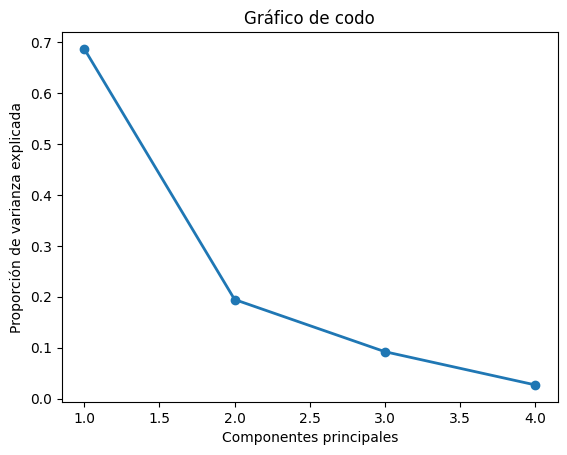

In [31]:
PC_values = np.arange(len(pca.explained_variance_ratio_)) + 1

plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2)
plt.title('Gráfico de codo')
plt.xlabel('Componentes principales')
plt.ylabel('Proporción de varianza explicada')
plt.show()

A partir del gráfico de codo, se observa una caída pronunciada en la varianza explicada entre el primer y segundo componente, y una disminución más gradual a partir del tercer componente. Esto indica que el “codo” del gráfico se encuentra alrededor del segundo componente, ya que a partir de ese punto la incorporación de nuevos componentes aporta cada vez menos información.

Por lo tanto, se puede considerar que **dos** componentes principales son suficientes para representar adecuadamente la estructura de los datos.

#### C)  Criterio de Kaiser

In [32]:
autovalores = pca.explained_variance_ 
autovalores

array([2.75362487, 0.7804609 , 0.36975289, 0.10820954])

El criterio de Kaisser indica que se deben aceptar los eigenvalues con un valor >= 1. Bajo este criterio, solo la **primera componente** cumple con ese criterio.

#### Conclusión:

Luego de analizar los tres criterios, se determina que PCA con **dos componentes** captura la estructura fundamental de los datos.

#### Visualización:

In [33]:
df_interactivo = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
df_interactivo['Especie'] = datos['Especie'].values

fig = px.scatter(df_interactivo,
    x='PC1',
    y='PC2',
    color='Especie',
    color_discrete_map=colores,
    title='Especies de Pingüinos por PCA',
    labels={'PC1': 'Componente 1 (68.6%)', 'PC2': 'Componente 2 (19.5%)'},
    opacity=0.8,
    width=800,
    height=600)

fig.show()

A partir de la proyección de las primeras dos componentes principales, se observa que la primera componente permite una clara separación de la especie Gentoo respecto de las demás.

Las especies Adelie y Chinstrap estan mas superpuestas, lo que indica que sus características son más similares.


### **3) Isomap**

Variación según componentes:

In [34]:
for n in [1, 2, 3, 4]:
    iso = Isomap(n_neighbors=15, n_components=n)
    iso.fit(X_scaled)
    print(f'Cant. componentes = {n} → error de reconstrucción: {iso.reconstruction_error():.3f}')

Cant. componentes = 1 → error de reconstrucción: 1.038
Cant. componentes = 2 → error de reconstrucción: 0.450
Cant. componentes = 3 → error de reconstrucción: 0.286
Cant. componentes = 4 → error de reconstrucción: 0.237


Variación según número de vecinos:

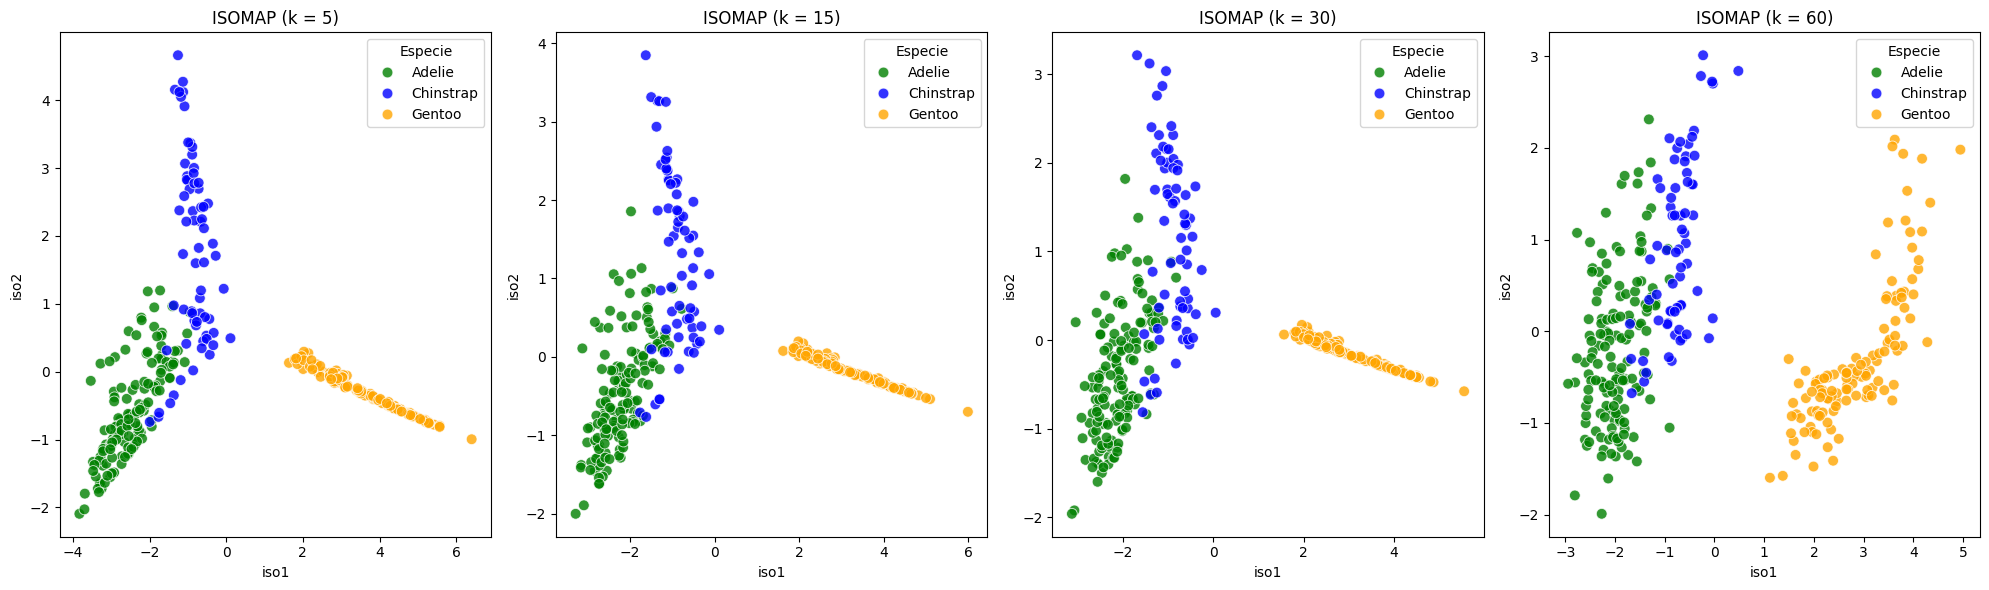

In [35]:
neighbors_list = [5, 15, 30, 60]

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for ax, k in zip(axes, neighbors_list):
    isomap = Isomap(n_neighbors=k, n_components=2)
    X_iso = isomap.fit_transform(X_scaled)

    df_iso = pd.DataFrame(X_iso, columns=['iso1', 'iso2'])
    df_iso['Especie'] = datos['Especie'].values

    sns.scatterplot(data=df_iso,x='iso1',y='iso2',hue='Especie',palette=colores, s=60,alpha=0.8,ax=ax)
    ax.set_title(f'ISOMAP (k = {k})')

plt.tight_layout()
plt.show()

#### Observaciones:

Según el número de componentes (con k fijo):

- Con **1 componente** el error es máximo (1.038 con k=15): 
  una sola dimensión resulta insuficiente para preservar la estructura de 
  distancias geodésicas del espacio original.
- El paso a **2 componentes** produce la mayor reducción del error, lo que indica que la segunda dimensión 
  aporta información sustancial.
- El paso a **3 componentes** reduce el error en torno al 36%, y el paso a 
  **4** solo entre 17% y 18%: los aportes marginales son decrecientes.
El punto de inflexión se ubica por lo tanto en **2 componentes**, como pasó con PCA.

Según el número de vecinos (con n_components fijo)

- **k = 5**: con una vecindad muy reducida la proyección enfatiza la 
  estructura local. Adelie y Chinstrap aparecen dispuestas en dos ramas que 
  convergen en una zona de contacto, con varios individuos ubicados en la 
  frontera entre ambos grupos. Gentoo se proyecta como una franja estrecha y 
  alargada.
- **k = 15**: la configuración general se mantiene, pero los grupos adquieren 
  mayor cohesión: Chinstrap se concentra en la zona superior de iso2 y Adelie 
  en la inferior, con una región de solapamiento en torno a iso2 ≈ 0. Gentoo 
  conserva la forma alargada y la separación sobre iso1.
- **k = 30**: la estructura se estabiliza y los grupos resultan más compactos. 
  La separación entre Adelie y Chinstrap sigue produciéndose principalmente 
  sobre iso2, aunque persiste una banda de individuos mezclados.
- **k = 60**: con vecindades amplias el método pierde sensibilidad a la 
  estructura local y la proyección se aproxima a una solución global. Gentoo 
  deja de presentarse como una franja comprimida y adopta una dispersión 
  bidimensional comparable a la de los demás grupos.

### **4) t-SNE:**

In [36]:
tsne = TSNE(n_components=2, init='random', random_state=42)
X_2D_tsne = tsne.fit_transform(X_scaled)
print(X_2D_tsne.shape)

tsne_df = pd.DataFrame(data=X_2D_tsne,columns=['tsne1', 'tsne2'])
tsne_df['Especie'] = datos['Especie'].values

(333, 2)


Variación de Parámetros:

**A) Componentes:**

In [37]:
for n in [1, 2, 3]:
    tsne = TSNE(n_components=n, perplexity=30, random_state=42)
    tsne.fit_transform(X_scaled)
    print(f'Cant. componentes = {n} → KL: {tsne.kl_divergence_:.4f}')

Cant. componentes = 1 → KL: 0.5286
Cant. componentes = 2 → KL: 0.3599
Cant. componentes = 3 → KL: 0.2603


KL mide cuánto difieren las similitudes entre pares de puntos en el espacio original respecto de las del espacio proyectado. Cuanto más baja, mejor preserva la proyección la estructura de vecindades. Por lo tanto, la caída mayor está al pasar de 1 a 2, y de 2 a 3 la mejora ya es menor.

**B) Perplexities:**

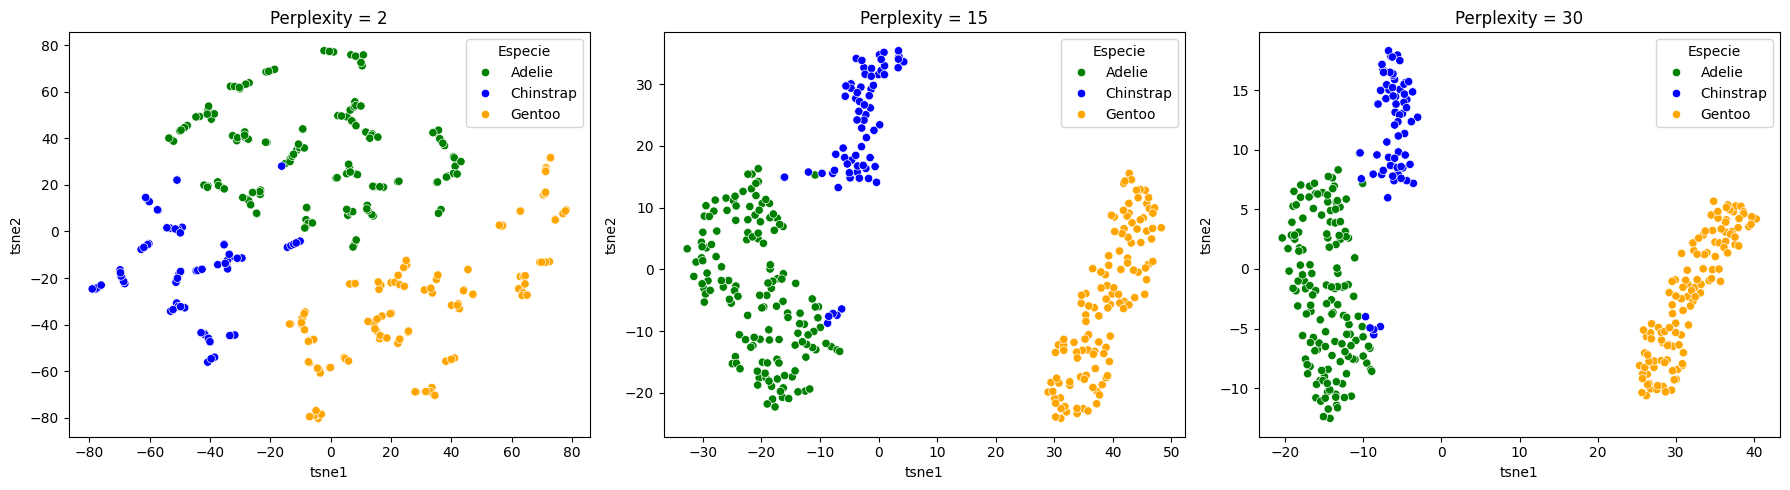

In [38]:
# 3 configuraciones a comparar
perplexities = [2, 15, 30]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, p in zip(axes, perplexities):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42) # dos comp.
    X_tsne = tsne.fit_transform(X_scaled)

    df_tsne = pd.DataFrame(X_tsne, columns=['tsne1','tsne2'])
    df_tsne['Especie'] = datos['Especie'].values

    sns.scatterplot(data=df_tsne, x='tsne1', y='tsne2', hue='Especie', ax=ax, palette=colores)
    ax.set_title(f'Perplexity = {p}')

plt.tight_layout()
plt.show()

**C) Iterations:**

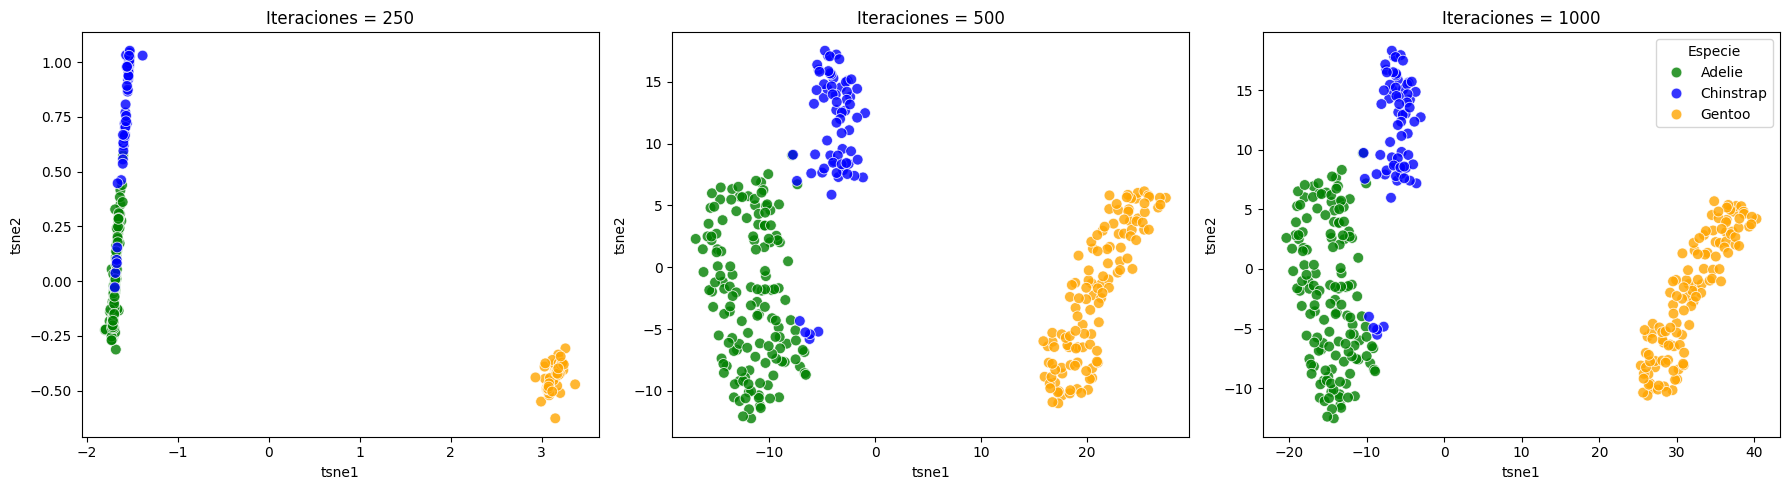

In [39]:
iterations = [250, 500, 1000]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, i in zip(axes, iterations):
    tsne = TSNE(n_components=2, perplexity=30, max_iter=i, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    df_tsne = pd.DataFrame(X_tsne, columns=['tsne1', 'tsne2'])
    df_tsne['Especie'] = datos['Especie'].values

    sns.scatterplot(data=df_tsne, x='tsne1', y='tsne2', hue='Especie',
                    palette=colores, s=60, alpha=0.8,
                    ax=ax, legend=(ax is axes[-1]))
    ax.set_title(f'Iteraciones = {i}')

plt.tight_layout()
plt.show()

#### Conclusión

Al variar los parámetros, se observó que la perplejidad 
tiene un impacto determinante sobre la estructura de la proyección. Con un 
valor bajo (2), el algoritmo considera vecindades demasiado reducidas y 
privilegia la estructura local: los grupos 
aparecen fragmentados en subconjuntos dispersos y Adelie y Chinstrap se 
entremezclan a lo largo de toda la proyección, sin que se distinga una 
separación entre especies. Con perplejidades de 15 y 30 la configuración se 
estabiliza y resulta muy similar entre ambas: Gentoo queda 
separada sobre tsne1, mientras que Adelie y Chinstrap conforman grupos 
diferenciados sobre tsne2 con una zona de contacto reducida.

En cuanto al número de iteraciones, con 250 la proyección resulta 
insuficiente: Adelie y Chinstrap permanecen colapsadas sobre una franja 
estrecha y solo Gentoo llega a separarse. Con 500 
iteraciones la estructura ya se encuentra desarrollada, y el 
resultado con 1000 es prácticamente idéntico, lo que indica que se alcanzó 
la convergencia.

En definitiva, se adopta configuración de perplejidad 30, 500 
iteraciones y 2 componentes. La estructura obtenida coincide con la 
identificada mediante PCA e Isomap: Gentoo se separa nítidamente del resto, 
mientras que Adelie y Chinstrap resultan más próximas 
entre sí.

### **5) K-means**

In [40]:
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    print(f'\nk = {k} -----------------')
    print(pd.crosstab(datos['Especie'], km.labels_))


k = 2 -----------------
col_0        0    1
Especie            
Adelie     146    0
Chinstrap   68    0
Gentoo       0  119

k = 3 -----------------
col_0        0    1   2
Especie                
Adelie     124    0  22
Chinstrap    5    0  63
Gentoo       0  119   0

k = 4 -----------------
col_0       0   1   2    3
Especie                   
Adelie      0  22   0  124
Chinstrap   0  63   0    5
Gentoo     57   0  62    0


Observaciones sobre la variación de clusters:

- k=2: separa Gentoo (119) del resto (214) con gran precisión. Esto confirma lo visto en PCA, Isomap y t-SNE.

- k=3: Gentoo sigue aislada. Los otros dos clusters separan Adelie de Chinstrap con 27 errores sobre 214 (22 Adelie asignadas al cluster de Chinstrap y 5 Chinstrap al de Adelie), o sea ~87% de correspondencia.

- k=4: los clusters de Adelie y Chinstrap quedan idénticos a k=3. Lo distinto es que se parte Gentoo, en 57 y 62. Tal vez tenga relación a los boxplots, en los que Gentoo mostraba la separación macho/hembra más marcada de las tres especies en masa corporal y longitud de aleta.

#### Criterio del Codo:

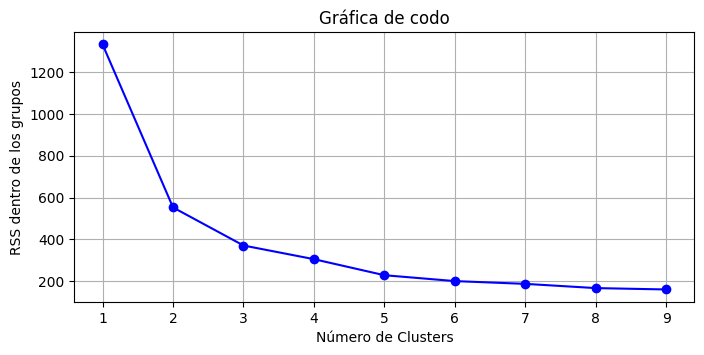

In [41]:
Nc = range(1, 10)
kmeans = [KMeans(n_clusters=k, random_state=42).fit(X_scaled) for k in Nc]

inertias = [model.inertia_ for model in kmeans]

plt.figure(figsize=(8, 3.5))
plt.plot(Nc,inertias, "bo-")
plt.xlabel('Número de Clusters')
plt.ylabel('RSS dentro de los grupos')
plt.title('Gráfica de codo')
plt.grid()
plt.show()

La mayor reducción de la inercia se produce al pasar de uno a dos clusters, seguida de una caída aún considerable hacia k = 3; a partir de k = 4 las disminuciones son marginales. El criterio admite por tanto lecturas en k = 2 o k = 3, lo cual es coherente con lo hecho anteriormente.

#### Cálculo y visualización de Silhouette y GAP

In [42]:
np.random.seed(42)

# 1. Función para la dispersión (usada en el Gap Statistic)
def calculate_intra_cluster_dispersion(X, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    return kmeans.inertia_

# 2. Función para el Silhouette Score
def calculate_silhouette(X_scaled, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_scaled, labels)
    sample_silhouette_values = silhouette_samples(X_scaled, labels)
    return silhouette_avg, sample_silhouette_values

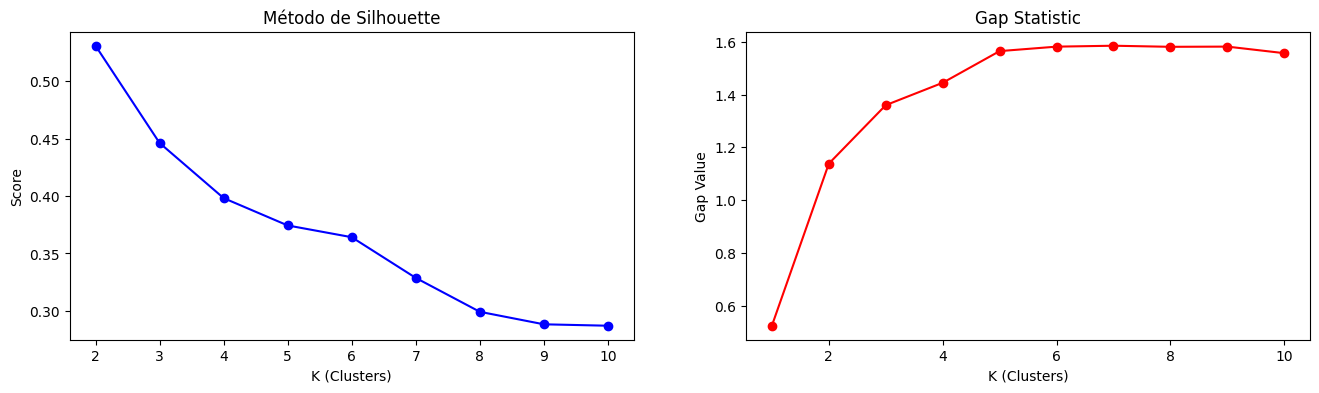

In [43]:
max_k = 10

# CÁLCULO DE SILHOUETTE
silhouette_scores = []
for k in range(2, max_k + 1):
    avg, _ = calculate_silhouette(X_scaled, k)
    silhouette_scores.append(avg)

# Referencia: datos uniformes sobre el rango real de cada variable
def generar_referencia(X):
    minimos, maximos = X.min(axis=0), X.max(axis=0)
    return np.random.uniform(minimos, maximos, size=X.shape)

# CÁLCULO DE GAP STATISTIC
n_simulaciones = 10
gaps = []
for k in range(1, max_k + 1):
    # Inercia real
    log_real = np.log(calculate_intra_cluster_dispersion(X_scaled, k))

    # Inercia de referencia (datos aleatorios sobre el rango de los datos)
    log_refs = []
    for _ in range(n_simulaciones):
        random_data = generar_referencia(X_scaled)
        log_refs.append(np.log(calculate_intra_cluster_dispersion(random_data, k)))

    gap = np.mean(log_refs) - log_real
    gaps.append(gap)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

# Gráfico Silhouette
ax1.plot(range(2, max_k + 1), silhouette_scores, marker='o', color='blue')
ax1.set_title('Método de Silhouette')
ax1.set_xlabel('K (Clusters)')
ax1.set_ylabel('Score')

# Gráfico Gap
ax2.plot(range(1, max_k + 1), gaps, marker='o', color='red')
ax2.set_title('Gap Statistic')
ax2.set_xlabel('K (Clusters)')
ax2.set_ylabel('Gap Value')

plt.show()

#### Conclusión

La mayor reducción de la inercia se produce al pasar de uno a dos clusters, seguida de una caída aún considerable hacia k = 3; a partir de k = 4 las disminuciones resultan marginales. El criterio admite por tanto lecturas en k = 2 o k = 3.

El score de Silhouette alcanza su máximo en k = 2 (0.53) y decrece de forma monótona al aumentar el número de clusters. Esto indica que la partición más limpia es la que distingue dos grupos, no tres.

El estadístico GAP presenta un crecimiento pronunciado hasta k = 3, que se atenúa marcadamente a partir de k = 4 (0.09) y se vuelve prácticamente nulo desde k = 5. Siguiendo el criterio de seleccionar el menor k, el valor indicado se ubica entre 2 y 3.

De forma definitiva, se adopta k = 3, en tanto los tres criterios resultan compatibles con ese 
valor y se corresponde con las tres especies presentes en el conjunto de 
datos. Este patrón es consistente con lo observado mediante PCA, Isomap y t-SNE, donde Gentoo se separa nítidamente del resto mientras que Adelie y Chinstrap presentan mayor proximidad.

#### Entrenamiento con k elegido:

In [44]:
kmeans = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=5, algorithm='lloyd')
kmeans.fit(X_scaled)

y_pred = kmeans.predict(X_scaled)

In [45]:
# Comprobamos que las etiquetas esten bien guardadas
np.array_equal(y_pred, kmeans.labels_)

True

In [46]:
np.set_printoptions(precision=6)
print("Centroides de los clusters:")
print(kmeans.cluster_centers_)
# caracteristicas normalizadas que tendria el centroide de ese cluster.

Centroides de los clusters:
[[-1.046809  0.486626 -0.881695 -0.762754]
 [ 0.654758 -1.102707  1.162463  1.101211]
 [ 0.672025  0.805263 -0.289347 -0.384104]]


In [47]:
columnas_numericas = ['Longitud Culmen (mm)', 'Profundidad Culmen (mm)', 'Longitud Aleta (mm)', 'Masa corporal (g)']

# DataFrame usando X_scaled
X_kmeans = pd.DataFrame(X_scaled, columns=columnas_numericas)

# Etiqueta del cluster que predijo K-Means
X_kmeans['cluster'] = kmeans.labels_

# Lo convertimos a categoría para que en los gráficos se trate como grupos distintos y no como un número continuo
X_kmeans['cluster'] = X_kmeans['cluster'].astype('category')

X_kmeans.head()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),cluster
0,-0.896042,0.780732,-1.426752,-0.568475,0
1,-0.822788,0.119584,-1.069474,-0.506286,0
2,-0.676280,0.424729,-0.426373,-1.190361,0
3,-1.335566,1.085877,-0.569284,-0.941606,0
4,-0.859415,1.747026,-0.783651,-0.692852,0


#### Visualización 3D:

In [48]:
colores_cluster = {0: 'green', 1: 'orange', 2: 'blue'}

fig_3 = px.scatter_3d(
    X_kmeans, # Usamos el DataFrame original de K=3
    x='Longitud Culmen (mm)',
    y='Longitud Aleta (mm)',
    z='Masa corporal (g)',
    color='cluster',
    color_discrete_map=colores_cluster,
    title='Clusters de K-Means (K=3): Hipótesis de Especies',
    labels={'cluster': 'Grupo Asignado (K=3)'},
    opacity=0.8
)
fig_3.show()

#### Observaciones:

La proyección sobre longitud del culmen, longitud de aleta y masa corporal muestra que uno de los clusters se distingue nítidamente de los restantes, ubicándose en la región de mayor masa corporal y longitud de aleta; corresponde a la especie Gentoo. Los otros dos grupos ocupan una región contigua y presentan una frontera difusa, con individuos próximos 
entre sí a ambos lados del límite. Esta configuración reproduce el patrón identificado mediante PCA, Isomap y t-SNE.

### **6) Clustering jerarquico**

#### Visualización Dendograma:

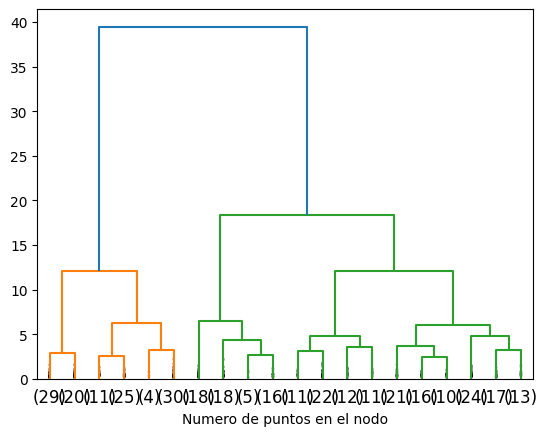

In [49]:
# Matriz de enlace
Z = linkage(X_scaled, method="ward")

# Dibuja un dendrograma truncado (solo muestra las últimas p hojas)
dendrogram(Z,  truncate_mode = 'lastp', p = 20, show_leaf_counts = True,
           show_contracted = True)
plt.axhline(y=110, c='k', linestyle='dashed')
plt.xlabel("Numero de puntos en el nodo")
plt.show()

Se observa una primera gran división de los datos en dos grupos principales. Al analizar niveles inferiores del árbol, uno de estos grupos se subdivide, mostrando tres clusters más específicos.

Si bien existe una separación clara en dos grandes conjuntos, hay una estructura más detallada que permite identificar tres grupos, lo cual es consistente con la presencia de tres especies en el dataset.

#### Cálculo y Visualización de Silhouette:

In [50]:
#Coeficiente de Silhouette
def calculate_silhouette(X_scaled, k, linkage='ward'):
    clustering = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = clustering.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, labels)
    sample_silhouette_values = silhouette_samples(X_scaled, labels)
    return silhouette_avg, sample_silhouette_values

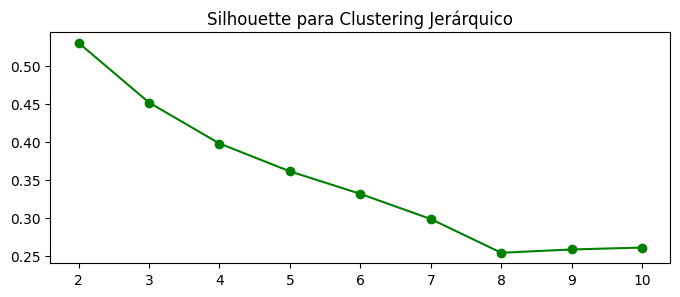

In [51]:
max_k = 10
silhouette_scores_hier = []

for k in range(2, max_k + 1):
    # Usamos la función del profe para Jerárquico
    silhouette_avg, _ = calculate_silhouette(X_scaled, k, linkage='ward')
    silhouette_scores_hier.append(silhouette_avg)

# Graficamos Silhouette para Jerárquico
plt.figure(figsize=(8, 3))
plt.plot(range(2, max_k + 1), silhouette_scores_hier, marker='o', color='green')
plt.title('Silhouette para Clustering Jerárquico')
plt.show()

A partir del análisis del coeficiente de Silhouette, se observa que el valor máximo se alcanza en k = 2, indicando que esta es la cantidad de clusters que mejor separa los datos.

El dendrograma muestra una separación clara pero deja observar otras subdivisiones dentro de los dos grupos.

Por lo tanto, se concluye que 2 clusters representan adecuadamente la estructura de los datos según el método jerárquico.

#### Cálculo y visualizacion de GAP Statictic:

In [52]:
def calculate_intra_cluster_dispersion(X, k):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    return kmeans.inertia_ # Retorna la suma de distancias al centroide

In [53]:
gaps = []
max_k = 10

# Calcula el Gap Statistic para determinar el número óptimo de clusters
for k in range(1, max_k + 1):
    # Calculo la inercia real sobre mis datos reales
    real_inertia = calculate_intra_cluster_dispersion(X_scaled, k)
    #Calculo la inercia de datos aleatorios con la misma estructura que mis datos originales
    inertia_list = []
    for _ in range(10):
      random_data = np.random.rand(*X_scaled.shape)
      intra_cluster_dispersion = calculate_intra_cluster_dispersion(random_data, k)
      inertia_list.append(intra_cluster_dispersion)

    reference_inertia = np.mean(inertia_list)

    gap = np.log(reference_inertia) - np.log(real_inertia)
    gaps.append(gap)

optimal_k = np.argmax(gaps) + 1


Número óptimo de clusters según el Gap Statistic: 4


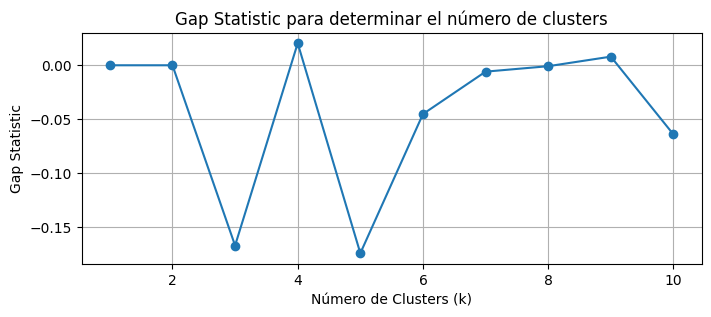

In [54]:
print("Número óptimo de clusters según el Gap Statistic:", optimal_k)

plt.figure(figsize=(8, 3))
plt.plot(range(1, max_k + 1), gaps, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic para determinar el número de clusters')
plt.grid()
plt.show()

A partir del cálculo del Gap Statistic, se observa que el valor máximo se alcanza en k = 5, lo que indica que esta es la cantidad óptima de clusters.

Este resultado sugiere que con 5 grupos se logra la mayor diferencia entre la dispersión de los datos reales y la de datos aleatorios, evidenciando una estructura bien definida en los datos.

Por lo tanto, según el criterio de GAP, el número adecuado de clusters es 5.

####  Conclusión:

El análisis mediante clustering jerárquico permitió visualizar la estructura de los datos sin necesidad de fijar un número de clusters. A partir del dendrograma, se observa que los datos presentan una primera gran división en dos grupos principales y subdivisiones posteriores que permiten identificar una mayor cantidad de clusters.

Si bien el criterio del Gap Statistic sugiere un número óptimo de clusters menor, el dendrograma muestra que también es posible interpretar la estructura en un mayor número de grupos, dependiendo del nivel de corte considerado. Una de las especies se diferencia claramente del resto, mientras que las otras presentan mayor similitud entre sí, lo que coincide con los resultados obtenidos en otros métodos de clustering.

Confirmamos que los datos poseen una estructura bien definida, aunque con distintos niveles de detalle, lo que explica las diferencias observadas entre los distintos criterios utilizados para determinar el número óptimo de clusters.

### CONCLUSIONES FINALES

A lo largo del análisis se aplicaron distintos métodos de reducción de dimensionalidad y clustering con el objetivo de identificar la estructura de los datos.

En primer lugar, técnicas como PCA, Isomap y t-SNE permitieron visualizar los datos en menor dimensión. Mientras que PCA capturó la variabilidad global, Isomap y t-SNE lograron representar mejor estructuras no lineales, evidenciando la posible existencia de varios grupos diferenciados.

Por otro lado, al aplicar métodos de clustering como K-Means y clustering jerárquico, se obtuvieron particiones consistentes. En particular, el clustering jerárquico, validado mediante el coeficiente de Silhouette y el Gap Statistic, indicó que el número óptimo de clusters es k = 5 .

En conjunto, los distintos enfoques coinciden en que los datos presentan una estructura interna clara con múltiples grupos bien definidos. Además, se destaca que los métodos no lineales (como t-SNE e Isomap) ofrecen una mejor representación visual de dicha estructura en comparación con técnicas lineales.

En conclusión, la combinación de técnicas permitió obtener una visión completa del dataset, validando la existencia de aproximadamente 3 clusters como una representación adecuada de los datos.
